## Run locally - news data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path)

    # Convert 'date' column to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Sort data
    df = df.sort_values(by='date', ascending=True) 

    # Round up to the next hour
    df['date'] = df['date'].dt.ceil('h')

    # Only select the 'sentiment_labels' column
    df = df[['date', 'sentiment_labels']]

    # Set index
    df.set_index('date', inplace=True)

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_news_data.csv")

In [4]:
df.head(20)

,sentiment_labels
date,
2011-06-22 11:00:00,negative
2012-02-01 19:00:00,neutral
2012-03-22 20:00:00,positive
2012-08-23 00:00:00,neutral
2012-09-07 14:00:00,neutral
2012-09-07 14:00:00,neutral
2012-10-29 13:00:00,positive
2012-11-30 23:00:00,negative
2012-12-09 09:00:00,positive


In [5]:
df.tail(20)

,sentiment_labels
date,
2024-01-23 23:00:00,negative
2024-01-24 01:00:00,neutral
2024-01-24 02:00:00,negative
2024-01-24 03:00:00,negative
2024-01-24 06:00:00,negative
2024-01-24 06:00:00,neutral
2024-01-24 07:00:00,positive
2024-01-24 10:00:00,negative
2024-01-24 10:00:00,positive


In [6]:
df.isna().sum()

sentiment_labels    0
dtype: int64

In [7]:
df.describe()

,sentiment_labels
count,80806
unique,3
top,positive
freq,41839


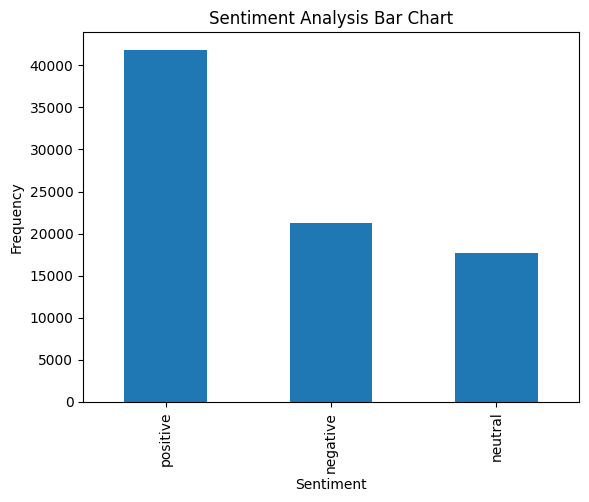

In [8]:
df['sentiment_labels'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis Bar Chart')
plt.xlabel('Sentiment')
plt.ylabel('Frequency');

### Create sentiment scores (-1, 0, 1) (average used)

In [9]:
# Define mapping for sentiment labels
sentiment_mapping = {'negative': -1, 'neutral': 0, 'positive': 1}

# Convert sentiment labels to numeric values
df['sentiment_score'] = df['sentiment_labels'].map(sentiment_mapping)

# Group by datetime index and take the average sentiment scores
df_cleaned = df.groupby(df.index)['sentiment_score'].mean()

# Convert Series to DataFrame
df_cleaned = df_cleaned.to_frame()

# Display cleaned DataFrame
df_cleaned.head()

,sentiment_score
date,
2011-06-22 11:00:00,-1.0
2012-02-01 19:00:00,0.0
2012-03-22 20:00:00,1.0
2012-08-23 00:00:00,0.0
2012-09-07 14:00:00,0.0


In [10]:
df_cleaned.tail()

,sentiment_score
date,
2024-01-24 13:00:00,0.000000
2024-01-24 14:00:00,0.666667
2024-01-24 15:00:00,-1.000000
2024-01-24 21:00:00,1.000000
2024-01-24 22:00:00,1.000000


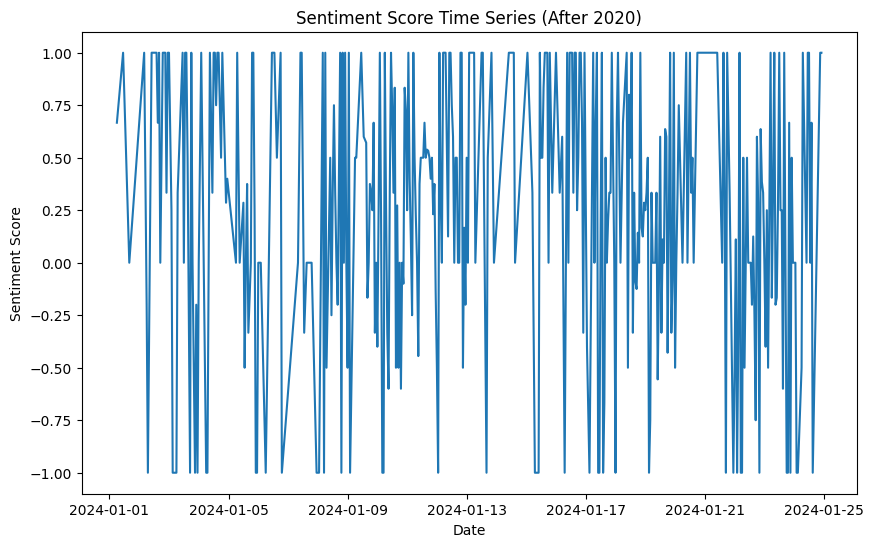

In [ ]:
# Filter data for dates after 2024
df_filtered = df_cleaned[df_cleaned.index >= '2024-01-01']

# Plot sentiment scores
plt.figure(figsize=(10, 6))
plt.plot(df_filtered.index, df_filtered['sentiment_score'])
plt.title('Sentiment Score Time Series')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.show()

In [12]:
df_cleaned.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_scores.csv")